# An Introduction to AION

Jeff Shen (<shenjeff@princeton.edu>)

7 April 2025

<br>
<br>
<br>

## First, an overview. 

AION consists of _tokenizers_ and a transformer encoder-decoder processor. The tokenizers are responsible for converting pixel-level data (images, spectra, ...) into _tokens_ which are standardized in format. The transformer is then responsible for modelling all the joint and conditional distributions of these tokens. Any input tokens will go through the encoder part and end up as _embeddings_ (some useful representation of the input data), which go into the decoder along with specified output modalities, to produce output tokens. 

### There are a few common things that you might want to do with AION. 

Here I will demonstrate:
- model loading
- tokenization
- sampling
- embedding-based adaptation

<br>
<br>
<br>

## Model loading

You will need to install the `AION` package from https://github.com/PolymathicAI/AION.

In [1]:
import torch
from aion import AION

Let's load the pretrained model. 

__Note__: this only loads the transformer, NOT the tokenizers.

In [2]:
model = AION.from_pretrained('/mnt/ceph/users/polymathic/aion/dec24/base')

Loading weights from local directory


### AION transformer

Now, we have access to the transformer model.

There are a few parts to this: the encoder embeddings, encoder, decoder embeddings, and decoder.

The encoder embeddings are responsible for taking the tokens from ints to vectors in a high dimensional space. The encoder processes these vectors and turns them into useful representations. From there, the decoder takes those input representations and gives you representations for the modalities you want. The decoder embeddings then turn those back into ints that you can decode back to pixel-level data. Let's look at some of these parts here.

Below are all the modalities that AION understands (i.e., is pretrained with):

In [3]:
model.encoder_embeddings.keys()

odict_keys(['catalog', 'tok_a_g', 'tok_a_i', 'tok_a_r', 'tok_a_y', 'tok_a_z', 'tok_dec', 'tok_ebv', 'tok_flux_bp_gaia', 'tok_flux_g', 'tok_flux_g_gaia', 'tok_flux_i', 'tok_flux_r', 'tok_flux_rp_gaia', 'tok_flux_w1', 'tok_flux_w2', 'tok_flux_w3', 'tok_flux_w4', 'tok_flux_z', 'tok_image', 'tok_image_hsc', 'tok_mag_g', 'tok_mag_i', 'tok_mag_r', 'tok_mag_y', 'tok_mag_z', 'tok_parallax', 'tok_ra', 'tok_segmap', 'tok_shape11', 'tok_shape12', 'tok_shape22', 'tok_shape_e1', 'tok_shape_e2', 'tok_shape_r', 'tok_spectrum_desi', 'tok_spectrum_sdss', 'tok_xp_bp', 'tok_xp_rp', 'tok_z'])

And let's take a quick look at the components of the decoder:

In [4]:
model.decoder

ModuleList(
  (0-11): 12 x DecoderBlock(
    (norm1): LayerNorm()
    (self_attn): NormAttention(
      (qkv): Linear(in_features=768, out_features=2304, bias=False)
      (attn_drop): Dropout(p=0.0, inplace=False)
      (proj): Linear(in_features=768, out_features=768, bias=False)
      (proj_drop): Dropout(p=0.0, inplace=False)
      (q_norm): LayerNorm()
      (k_norm): LayerNorm()
    )
    (cross_attn): NormCrossAttention(
      (q): Linear(in_features=768, out_features=768, bias=False)
      (kv): Linear(in_features=768, out_features=1536, bias=False)
      (attn_drop): Dropout(p=0.0, inplace=False)
      (proj): Linear(in_features=768, out_features=768, bias=False)
      (proj_drop): Dropout(p=0.0, inplace=False)
      (q_norm): LayerNorm()
      (k_norm): LayerNorm()
    )
    (query_norm): LayerNorm()
    (context_norm): LayerNorm()
    (drop_path): Identity()
    (norm2): LayerNorm()
    (mlp): GatedMlp(
      (fc1): Linear(in_features=768, out_features=2048, bias=False)
    

### Model freezing

Here I will not be doing any fine tuning of the actual transformer. So I will freeze all the components. I will also put the model on GPU.

In [5]:
model.freeze_encoder(freeze_embeddings=True)
model.freeze_decoder(freeze_embeddings=True)

model = model.cuda().eval()

## Tokenizer loading

_If you are only working at the token level, you can skip this step._

We also need to load the tokenizers to work with raw pixel-level data. For this demo, I will use spectra, and so I will load the spectrum tokenizer. In general, you will need to load the tokenizer for each of the modalities you want to work with. 

### TODO: make tokenizer loading easier (I don't want to have to hunt for the path)

In [6]:
from aion.tokenizers import load_tokenizer
from aion.utils import to

In [7]:
 # for DESI spectra
tokenizer_spec = load_tokenizer(
    "/mnt/ceph/users/polymathic/MMOMA/outputs/mmoma_codec_sdss+desi/6kzi0iz9/checkpoints/last.pt", 
    device='cuda'
)

# for Gaia XP spectra
tokenizer_bp = load_tokenizer(
    "/mnt/ceph/users/polymathic/mmoma/outputs/mmoma_codec_parallax_1024/bp_coefficients_codec.pt",
    device='cpu',
)
tokenizer_rp = load_tokenizer(
    "/mnt/ceph/users/polymathic/mmoma/outputs/mmoma_codec_parallax_1024/rp_coefficients_codec.pt",
    device='cpu'
)

/mnt/home/jshen/miniconda3/envs/mmoma/lib/python3.10/site-packages/torch/package/package_importer.py:235: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  dtype = storage_type.dtype


<br>
<br>
<br>

## Tokenization

Since AION's transformer works at the token level, we need to give it inputs it understands. Here I will show how you can turn raw (pixel-level) data to tokens.

### Data loading

Ok, let's get some data to play with. For this example I will use low-res spectra (in the form of basis coefficients) from _Gaia_ and medium-res spectra from DESI, but it doesn't matter where you get your data from, as long as it is formatted in the right way. I will not talk about that too much here because it is different for each modality; you will need to check the specifications of the tokenizers to how they need their inputs formatted.

In [8]:
from mmoma.datasets.astropile import CrossMatchedAstroPileLoader
from mmoma.datasets.preprocessing import PadSpectra
import matplotlib.pyplot as plt

In [9]:
dm = CrossMatchedAstroPileLoader(
    left_dataset_path="/mnt/ceph/users/polymathic/MultimodalUniverse/desi",
    right_dataset_path="/mnt/ceph/users/flanusse/myGaia/gaia.py",
    left_dataset_name=None,
    right_dataset_name="parallax_sample",
    formatting_fns=[
        PadSpectra(max_length=7800),
    ],
    batch_size=128,
    num_workers=8,
    exclude_healpix=None,
    include_healpix=[1708,1709,1643,1640,1642,2698,1081,74,2096,132],
)
dm.setup("")
loader = dm.train_dataloader()

Resolving data files:   0%|          | 0/61 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/3072 [00:00<?, ?it/s]

Number of common healpix regions:  5


In [10]:
batch = next(iter(loader))

Let's see what we have in our data batch:

In [11]:
batch.keys()

dict_keys(['object_id', 'desi_spectrum', 'desi_Z', 'desi_ZERR', 'desi_EBV', 'desi_FLUX_G', 'desi_FLUX_R', 'desi_FLUX_Z', 'desi_FLUX_IVAR_G', 'desi_FLUX_IVAR_R', 'desi_FLUX_IVAR_Z', 'desi_FIBERFLUX_G', 'desi_FIBERFLUX_R', 'desi_FIBERFLUX_Z', 'desi_FIBERTOTFLUX_G', 'desi_FIBERTOTFLUX_R', 'desi_FIBERTOTFLUX_Z', 'desi_object_id', 'gaia_object_id', 'gaia_phot_g_mean_mag', 'gaia_phot_bp_mean_mag', 'gaia_phot_rp_mean_mag', 'gaia_bp_coefficients', 'gaia_rp_coefficients', 'gaia_parallax', 'gaia_ra', 'gaia_dec', 'gaia_pmra', 'gaia_pmdec'])

Here we are interested in `desi_spectrum`, `gaia_bp_coefficients`, and `gaia_rp_coefficients`.

## Tokenize

Again, you will need to ensure that your inputs are suitable for the tokenizer. Then we can call `encode` on our raw inputs to turn them into tokens.

In [12]:
with torch.no_grad():
    tok_spec = tokenizer_spec.encode(
        dict(spectrum=to(batch['desi_spectrum'], "cuda"))
    )
    tok_bp = tokenizer_bp.encode(
        dict(bp_coefficients=batch['gaia_bp_coefficients'])
    )
    tok_rp = tokenizer_rp.encode(
        dict(rp_coefficients=batch['gaia_rp_coefficients'])
    )

In [13]:
tok_spec.shape, tok_bp.shape, tok_rp.shape

(torch.Size([128, 273]), torch.Size([128, 55]), torch.Size([128, 55]))

Here the tokens are of shape `[batch, sequence]`.

Now that we have our tokens, we can do interesting things with them.

<br>
<br>
<br>

## Sampling

Here I will demonstrate __sampling__. That is, given some input modality $x$ and some desired output modality $y$, I will draw samples from the conditional distribution $p(y|x)$.

More concretely, I will demonstrate spectrum super-resolution: given (the basis coefficients of) a low-res spectrum from _Gaia_, I will generate (samples of) the corresponding high-res spectrum from DESI. You can use the same strategy to sample from modalities that AION understands, and can even do things like cross-modal generation (e.g., from an image to a spectrum).

We first need to initialize a sampler object

In [14]:
from aion.fourm.generate import GenerationSampler, build_chained_generation_schedules, init_empty_target_modality, init_full_input_modality
from aion.fourm.modality_info import MODALITY_INFO

In [15]:
sampler = GenerationSampler(model)

Then we set up the generation by specifying the input and output modalities. The modalities that the model understands are from the `model.encoder_embeddings.keys()` from above. We also need to specify how many tokens the target modality has. Since I am generating `tok_spectrum_desi`, if we remember from above, this has 273 tokens (the sequence length).

In [16]:
input_mod = ['tok_xp_bp', 'tok_xp_bp']
target_mod = ['tok_spectrum_desi']
tokens_per_target = [273]

### Setting up the inputs
We then prepare the inputs into a dictionary where each modality gets a key, and the corresponding value contains another dictionary with the actual tokens, and an input and output mask.

In [17]:
device = 'cuda' # where to run the model

prepared_input_tokens = dict(
    tok_xp_bp=tok_bp,
    tok_xp_rp=tok_rp,
)

batched_sample = {
    k: dict(
        tensor=v.to(device).int(),
        input_mask=torch.zeros_like(v, dtype=torch.bool, device=device), # False = used as input, True = ignored
        target_mask=torch.ones_like(v, dtype=torch.bool, device=device), # False = predicted as target, True = ignored
    ) for k, v in prepared_input_tokens.items()
}

# Initialize input modalities
for im in input_mod:
    batched_sample = init_full_input_modality(batched_sample, MODALITY_INFO, im, device)

for tm, ntoks in zip(target_mod, tokens_per_target):
    batched_sample = init_empty_target_modality(batched_sample, MODALITY_INFO, tm, batched_sample[im]['tensor'].shape[0], ntoks, device)

### Setting up the sampler

We need to set up the sampling schedule so that the sampler knows how we want to generate the output tokens.

In [18]:
schedule = build_chained_generation_schedules(
    cond_domains=input_mod, 
    target_domains=target_mod, 
    tokens_per_target=tokens_per_target, 

    # for args below, you will need one list item per target modality. here that is just 1
    
    autoregression_schemes=['roar'], # roar, autoregressive, maskgit
    decoding_steps=[25], # how many steps to decode all the tokens
    token_decoding_schedules=['linear'], # constant, linear
    temps=[0.4], # sampling temperature, higher=more diversity
    temp_schedules=['constant'], # constant, linear
    cfg_scales=[1.0], # for classifier free guidance
    cfg_schedules=['constant'],
)

Now we are ready to do actual sampling! Note that the sampler will overwrite the input dictionary.

In [19]:
batched_sample = sampler.generate(batched_sample, schedule, verbose=True, seed=0)

25it [00:07,  3.37it/s]


### Decoding and checking

Ok, now that we have our sampled tokens, we want to see what they look like. To do this, we will decode them back to pixel-level spectra and plot them. Again, we use the tokenizer for this.

In [20]:
out_tok = batched_sample['tok_spectrum_desi']['tensor'] # grab the actual output tokens that we sampled

with torch.no_grad():
    out_spec = to(tokenizer_spec.decode(out_tok, ctx=dict(spectrum=to(batch['desi_spectrum'], "cuda"))), "cpu") # decode

Now let's compare the sampled spectra to the real spectra!

Text(0, 0.5, 'Flux')

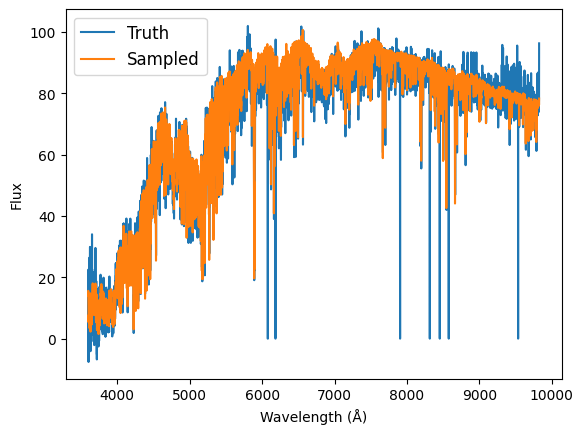

In [21]:
ix = 0
mask = batch['desi_spectrum']['lambda'][ix] < 99999
plt.plot(batch['desi_spectrum']['lambda'][ix][mask], batch['desi_spectrum']['flux'][ix][mask], label='Truth')
plt.plot(batch['desi_spectrum']['lambda'][ix][mask], out_spec['spectrum']['flux'][ix][mask], label='Sampled')
plt.legend(fontsize=12)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")

Congrats, you successfully super-resolved some spectra!

<br>
<br>
<br>

## Embedding-based adaptation

Next, I will demonstrate how you can quickly adapt AION to perform downstream tasks based on embeddings. Here I will demonstrate parameter regression for stars.

The idea is that AION has been pretrained on vast amounts of data and has a good general understanding of stars. So, despite not being explicitly told anything about physical parameters, if we give it some input data, at the end of the encoder (we will not be using the decoder here), we will have some useful representation (embeddings) in which "important" information about stars is linearly accessible. We will take advantage of this fact to build a simple projection matrix to access this information and to tie it to some physical properties.

### Data

Here I will be using _Gaia_ XP coefficients again as the inputs, and as outputs some stellar parameters. Let's first get the data to train on. We will use the STARHORSE catalog which provides estimates for stellar parameters for APOGEE stars. Let's download it:

In [162]:
!wget "https://data.sdss.org/sas/dr17/env/APOGEE_STARHORSE/APOGEE_DR17_EDR3_STARHORSE_v2.fits"


04/07 13:10:05 [NOTICE] Downloading 1 item(s)
[#cc2e5e 275MiB/275MiB(99%) CN:1 DL:27MiB]0m]m
04/07 13:10:17 [NOTICE] Download complete: /mnt/ceph/users/jshen/programs/AION/examples/APOGEE_DR17_EDR3_STARHORSE_v2.fits

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
cc2e5e|OK  |    24MiB/s|/mnt/ceph/users/jshen/programs/AION/examples/APOGEE_DR17_EDR3_STARHORSE_v2.fits

Status Legend:
(OK):download completed.


Now let's load the data and extract the IDs of the stars for cross matching with Gaia and also extract the target labels we want to predict. Here that will be median estimates for Teff, logg, and [M/H].

In [22]:
from astropy.table import Table
import numpy as np

In [23]:
t = Table.read("APOGEE_DR17_EDR3_STARHORSE_v2.fits")

In [24]:
starhorse_ids = np.array(t['EDR3_source_id']).astype(int)
targets = np.array(t[['teff50', 'logg50', 'met50']]).view("<f4").reshape(len(t), 3)

### Cross-match

Let's do a simple cross match with some _Gaia_ data in a single healpix where I know a priori there is some overlap (there are of course more careful/realistic ways of doing this, but this is just a simple demo, so it doesn't really matter). We'll pull out all the XP coefficients and save the ones for the matches.

In [25]:
from tqdm.auto import tqdm
from mmoma.datasets.astropile import FastAstroPileLoader

In [26]:
dm = FastAstroPileLoader(
    "/mnt/home/polymathic/ceph/MultimodalUniverse/gaia_v2/", 
    dataset_name="dr3_xp", 
    include_healpix=[2068],
    num_workers=8,
)
dm.setup("")
loader = dm.train_dataloader()

Resolving data files:   0%|          | 0/3072 [00:00<?, ?it/s]

In [27]:
saved_gaia_ids = []
saved_bp = []
saved_rp = []
saved_labels = []

for batch in tqdm(loader):
    gaia_ids = np.asarray(batch['object_id'], dtype=int)
    _, gaia_ix, starhorse_ix = np.intersect1d(gaia_ids, starhorse_ids, return_indices=True)

    saved_gaia_ids.append(gaia_ids[gaia_ix])
    saved_bp.append(batch['bp_coefficients'][gaia_ix])
    saved_rp.append(batch['rp_coefficients'][gaia_ix])
    saved_labels.append(targets[starhorse_ix])

saved_gaia_ids = torch.from_numpy(np.concatenate(saved_gaia_ids))
saved_bp = torch.from_numpy(np.concatenate(saved_bp))
saved_rp = torch.from_numpy(np.concatenate(saved_rp))
saved_labels = torch.from_numpy(np.concatenate(saved_labels))

0it [00:00, ?it/s]

In [28]:
saved_bp.shape, saved_rp.shape, saved_labels.shape

(torch.Size([2274, 55]), torch.Size([2274, 55]), torch.Size([2274, 3]))

## Extracting embeddings

We now want to turn our XP coefficients into useful embeddings. We do this by tokenizing as before, then sending those tokens only through the encoder portion of AION.

In [29]:
tok_bp = tokenizer_bp.encode(dict(bp_coefficients=saved_bp))
tok_rp = tokenizer_rp.encode(dict(rp_coefficients=saved_rp))

In [30]:
tok_bp.shape, tok_rp.shape

(torch.Size([2274, 55]), torch.Size([2274, 55]))

In [31]:
with torch.no_grad():
    embeddings = model.encode(
        dict(
            tok_xp_bp=tok_bp,
            tok_xp_rp=tok_rp,
        )
    ).cpu()

In [32]:
embeddings.shape

torch.Size([2274, 110, 768])

### A note on pooling

Now that we have our embeddings, we can learn a linear mapping from those to whatever we want to predict. Note that the embeddings have shape `[batch, sequence, channel]`. We need to first reduce/flatten the sequence dimension (which represents the different token sequence lengths). Here I will do the simplest thing and average over them. There are more sophisticated ways to do this; for example, you can do cross-attention pooling with a learnable query for better performance.

In [33]:
mean_pooled_embeddings = embeddings.mean(axis=1)

### Train-test split

Let's split our data in the standard way to get a training and testing set.

In [34]:
randperm = torch.randperm(len(embeddings))
train_size = int(0.8 * len(randperm))
train_ix = randperm[:train_size]
test_ix = randperm[train_size:]

In [35]:
train_x, test_x = mean_pooled_embeddings[train_ix], mean_pooled_embeddings[test_ix]
train_y, test_y = saved_labels[train_ix], saved_labels[test_ix]

### Fit the projection matrix

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
adapter = LinearRegression(n_jobs=-1)

In [44]:
%time adapter.fit(train_x, train_y)

CPU times: user 644 ms, sys: 0 ns, total: 644 ms
Wall time: 96.4 ms


LinearRegression(n_jobs=-1)

In [45]:
pred_y = adapter.predict(test_x)

### Check predictions

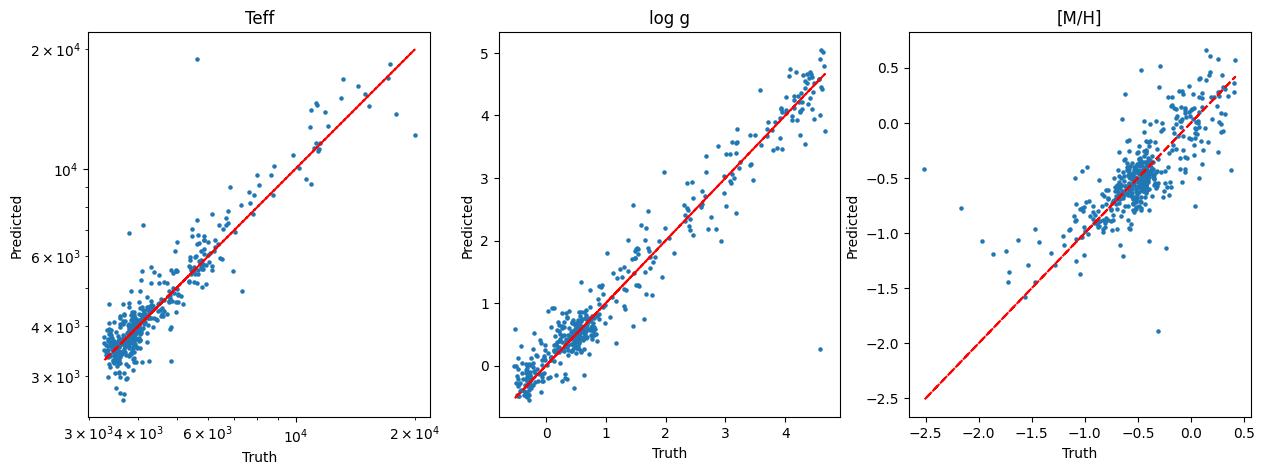

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

titles = ['Teff', 'log g', '[M/H]']

for i, j in enumerate(titles):
    ax[i].scatter(test_y[:,i], pred_y[:,i], s=5)
    ax[i].plot(test_y[:,i], test_y[:,i], 'r--')
    ax[i].set_title(j)
    ax[i].set_xlabel("Truth")
    ax[i].set_ylabel("Predicted")
    if i == 0:
        ax[i].set_xscale("log")
        ax[i].set_yscale("log")

Congrats, you have just done embedding-based adaptation!